In [ ]:
#input files. Do not touch.
import pandas as pd
import glob
import re

# Load training.csv
training = pd.read_csv("training.csv")

# Load all evalN.csv files into separate dataframes named evaluationN
eval_files = glob.glob("eval*.csv")
for f in eval_files:
    match = re.search(r'eval(\d+)\.csv', f)
    if match:
        n = match.group(1)
        df_name = f"evaluation{n}"
        globals()[df_name] = pd.read_csv(f)
        print("found evaluation dataset n°: " + df_name)

found evaluation dataset n°: evaluation1
found evaluation dataset n°: evaluation2
found evaluation dataset n°: evaluation3
found evaluation dataset n°: evaluation6
found evaluation dataset n°: evaluation4
found evaluation dataset n°: evaluation5


In [ ]:

def ids(eval_df):
    # ============================================================
    # Imports and Configuration
    # ============================================================
    import json
    import re
    from dataclasses import dataclass
    from datetime import datetime, timezone
    from pathlib import Path
    from typing import Any, Dict, Iterable, List, Optional, Sequence, Set, Tuple

    import numpy as np

    # ============================================================
    # USER CONFIGURATION
    # ============================================================

    # Saved profile created by the training/calibration stage and reused by prediction when available.
    DETECTOR_PROFILE_FILE = "can_detector_profile.json"

    # Set this to True only when you want to create/update DETECTOR_PROFILE_FILE.
    RUN_TRAINING_STAGE = False

    TIMESTAMP_COL = "timestamp"
    ARBITRATION_ID_COL = "arbitration_id"
    DATA_FIELD_COL = "data_field"
    LABEL_COL = "attack"
    BYTE_COLS = None

    # Feature extraction settings. These match the original ML notebook defaults and
    # are also overridden by the saved JSON profile when that profile is available.
    MAX_PAYLOAD_BYTES = 8
    ROLLING_PACKET_WINDOW = 100
    TIME_WINDOW_SECONDS = 1.0

    # Rule calibration settings.
    HIGH_QUANTILE = 0.995
    LOW_QUANTILE = 0.005
    MIN_ATTACK_SCORE = 0.5

    # Rule scores.
    LOW = 0.125
    MEDIUM = 0.25
    HIGH = 0.375
    TRIGGER = 0.5
    PRIORITY = 1.0


    # ============================================================
    # GLOBAL CONSTANTS AND CONFIGURATION
    # ============================================================

    CAN_CLASSIC_MAX_BYTES = 8
    CAN_FD_MAX_BYTES = 64
    STANDARD_CAN_MAX_ID = 0x7FF
    EXTENDED_CAN_MAX_ID = 0x1FFFFFFF
    HEX_PATTERN = re.compile(r"^[0-9A-F]*$")


    @dataclass
    class CANColumnConfig:
        """
        Central place to adapt the notebook to different datasets.
        """

        timestamp_col: str = "timestamp"
        arbitration_id_col: str = "arbitration_id"
        data_field_col: str = "data_field"
        label_col: Optional[str] = "attack"
        byte_cols: Optional[List[str]] = None


    def build_column_config() -> CANColumnConfig:
        return CANColumnConfig(
            timestamp_col=TIMESTAMP_COL,
            arbitration_id_col=ARBITRATION_ID_COL,
            data_field_col=DATA_FIELD_COL,
            label_col=LABEL_COL,
            byte_cols=BYTE_COLS,
        )

    CORE_FEATURE_COLUMNS = [
        "delta_t_global_s",
        "delta_t_same_id_s",
        "packet_rate_last_time_window_hz",
        "same_id_rate_last_time_window_hz",
        "consecutive_id_streak_length",
        "prev_arbitration_id",
        "rolling_unique_id_count",
        "rolling_id_entropy_bits",
        "payload_byte_sum",
        "payload_byte_entropy_bits",
        "payload_hamming_distance_prev_same_id",
    ]


    # ============================================================
    # COLUMN STANDARDIZATION
    # ============================================================


    def _build_data_field_from_byte_columns(
        raw_df: pd.DataFrame,
        byte_cols: Sequence[str],
    ) -> pd.Series:
        """
        Convert separate byte columns into one hexadecimal data_field string.
        """

        def row_to_hex(row: pd.Series) -> str:
            payload_parts: List[str] = []

            for col in byte_cols:
                value = row.get(col, np.nan)

                if pd.isna(value):
                    continue

                try:
                    byte_value = int(value)
                except (TypeError, ValueError):
                    try:
                        text = str(value).strip().upper()
                        if text.startswith("0X"):
                            text = text[2:]
                        byte_value = int(text, 16)
                    except (TypeError, ValueError):
                        continue

                if 0 <= byte_value <= 255:
                    payload_parts.append(f"{byte_value:02X}")

            return "".join(payload_parts)

        return raw_df.apply(row_to_hex, axis=1)


    def standardize_raw_can_columns(
        raw_df: pd.DataFrame,
        config: CANColumnConfig,
    ) -> pd.DataFrame:
        """
        Convert different dataset schemas into the canonical schema expected by
        preprocess_can_dataframe():

            timestamp
            arbitration_id
            data_field
            attack

        The true label is copied to __true_label and is never used for feature
        extraction or rule calibration.
        """
        df = raw_df.copy()

        required = [config.timestamp_col, config.arbitration_id_col]
        missing = [col for col in required if col not in df.columns]
        if missing:
            raise ValueError(f"Missing required input columns: {missing}")

        standardized = pd.DataFrame(index=df.index)
        standardized["__input_order"] = np.arange(len(df), dtype="int64")
        standardized["timestamp"] = df[config.timestamp_col]
        standardized["arbitration_id"] = df[config.arbitration_id_col]

        if config.data_field_col in df.columns:
            standardized["data_field"] = df[config.data_field_col]
        elif config.byte_cols is not None:
            missing_bytes = [col for col in config.byte_cols if col not in df.columns]
            if missing_bytes:
                raise ValueError(f"Missing byte columns: {missing_bytes}")
            standardized["data_field"] = _build_data_field_from_byte_columns(df, config.byte_cols)
        else:
            raise ValueError("No data_field column found and no byte_cols were provided.")

        if config.label_col is not None and config.label_col in df.columns:
            standardized["__true_label"] = df[config.label_col].values

        # Added for compatibility with preprocessing; it is dropped immediately.
        standardized["attack"] = 0

        return standardized


    # ============================================================
    # PREPROCESSING HELPERS
    # ============================================================

    def _parse_can_identifier(value: object) -> float:
        """
        Parse arbitration IDs robustly.

        Rules:
          - 0x-prefixed values are parsed as hexadecimal.
          - Values containing A-F are parsed as hexadecimal.
          - Digit-only values are parsed as decimal.
          - Invalid or out-of-range values become NaN.
        """
        if pd.isna(value):
            return np.nan

        text = str(value).strip().upper()
        if not text:
            return np.nan

        try:
            if text.startswith("0X"):
                parsed = int(text[2:], 16)
            elif any(ch in text for ch in "ABCDEF"):
                parsed = int(text, 16)
            else:
                parsed = int(text, 10)
        except (TypeError, ValueError):
            return np.nan

        if parsed < 0 or parsed > EXTENDED_CAN_MAX_ID:
            return np.nan

        return float(parsed)


    def _normalize_payload_hex(value: object) -> Tuple[str, bool, bool, bool]:
        """
        Normalize CAN data_field into uppercase hexadecimal text.

        Returns:
          normalized_hex, is_valid_hex, is_missing, has_odd_nibble_count
        """
        if pd.isna(value):
            return "", False, True, False

        text = str(value).strip().upper()

        if text.startswith("0X"):
            text = text[2:]

        # Remove common separators from logs.
        for sep in (" ", "-", ":", "_", ","):
            text = text.replace(sep, "")

        if text == "":
            return "", False, True, False

        contains_only_hex = bool(HEX_PATTERN.fullmatch(text))
        odd_nibbles = len(text) % 2 == 1
        is_valid_hex = contains_only_hex and not odd_nibbles

        return text, is_valid_hex, False, odd_nibbles


    # ============================================================
    # PREPROCESSING
    # ============================================================

    def preprocess_can_dataframe(
        raw_df: pd.DataFrame,
        *,
        max_payload_bytes: int = CAN_CLASSIC_MAX_BYTES,
    ) -> pd.DataFrame:
        """
        Convert raw CAN packets into a compact, rule-ready representation.

        The earlier notebook unfolded many byte, nibble, bit, and binary-string
        columns. This simplified version keeps only fields needed for rules,
        diagnostics, and final display.
        """
        if max_payload_bytes < 1 or max_payload_bytes > CAN_FD_MAX_BYTES:
            raise ValueError("max_payload_bytes must be between 1 and 64.")

        df = raw_df.copy()

        # Drop attack-like column immediately. Evaluation labels should be stored
        # in __true_label before this point.
        if "attack" in df.columns:
            df = df.drop(columns=["attack"])

        required_columns = {"timestamp", "arbitration_id", "data_field"}
        missing = required_columns.difference(df.columns)
        if missing:
            raise ValueError(f"Missing required columns: {sorted(missing)}")

        # Timestamp processing.
        df["timestamp_raw"] = df["timestamp"]
        df["timestamp_seconds"] = pd.to_numeric(df["timestamp"], errors="coerce")
        df["timestamp_parse_valid"] = df["timestamp_seconds"].notna()

        # Stable chronological sort keeps equal timestamps in original order.
        df = df.sort_values(
            "timestamp_seconds",
            kind="mergesort",
            na_position="last",
        ).reset_index(drop=True)

        first_valid_ts = df["timestamp_seconds"].dropna().min()
        if pd.isna(first_valid_ts):
            first_valid_ts = 0.0
        df["time_from_start_s"] = df["timestamp_seconds"] - first_valid_ts

        # Arbitration ID processing.
        df["arbitration_id_raw"] = df["arbitration_id"]
        df["arbitration_id"] = df["arbitration_id"].map(_parse_can_identifier)
        df["arbitration_id_parse_valid"] = df["arbitration_id"].notna()
        df["arbitration_id_hex"] = df["arbitration_id"].map(
            lambda x: f"0x{int(x):X}" if pd.notna(x) else pd.NA
        )

        # Payload processing.
        df["data_field_raw"] = df["data_field"]
        payload_parts = pd.DataFrame(
            df["data_field"].map(_normalize_payload_hex).tolist(),
            columns=[
                "payload_hex_normalized",
                "payload_is_valid_hex",
                "payload_is_missing",
                "payload_has_odd_nibble_count",
            ],
            index=df.index,
        )
        df = pd.concat([df, payload_parts], axis=1)

        dlc = np.where(
            df["payload_is_valid_hex"],
            df["payload_hex_normalized"].str.len() // 2,
            np.nan,
        )
        df["dlc"] = pd.Series(dlc, index=df.index, dtype="float64").astype("Int64")
        df["payload_exceeds_configured_length"] = df["dlc"].fillna(0) > max_payload_bytes

        # Preserve parsed columns; remove raw ambiguous working inputs.
        df = df.drop(columns=["timestamp", "data_field"])

        return df


    # ============================================================
    # COMPACT FEATURE EXTRACTION HELPERS
    # ============================================================

    def _safe_entropy_from_values(values: Iterable[Any]) -> float:
        """
        Shannon entropy in bits for finite values.
        """
        arr = pd.Series(list(values)).dropna().to_numpy()

        if arr.size == 0:
            return np.nan

        _, counts = np.unique(arr, return_counts=True)
        probabilities = counts / counts.sum()
        probabilities = probabilities[probabilities > 0]

        return float(-(probabilities * np.log2(probabilities)).sum())


    def _rolling_entropy_numeric(
        series: pd.Series,
        window: int,
        min_periods: int,
    ) -> pd.Series:
        return series.rolling(window=window, min_periods=min_periods).apply(
            _safe_entropy_from_values,
            raw=False,
        )


    def _count_in_previous_seconds(
        timestamps: np.ndarray,
        window_seconds: float,
    ) -> np.ndarray:
        """
        Count packets in [t - window_seconds, t].
        """
        out = np.full(len(timestamps), np.nan, dtype="float64")
        valid_positions = np.flatnonzero(np.isfinite(timestamps))

        if valid_positions.size == 0:
            return out

        valid_t = timestamps[valid_positions]
        left = np.searchsorted(valid_t, valid_t - window_seconds, side="left")
        out[valid_positions] = np.arange(valid_t.size) - left + 1

        return out


    def _group_count_in_previous_seconds(
        df: pd.DataFrame,
        id_col: str,
        time_col: str,
        window_seconds: float,
    ) -> np.ndarray:
        out = np.full(len(df), np.nan, dtype="float64")
        timestamps = df[time_col].to_numpy(dtype="float64")

        for _, index_values in df.groupby(id_col, sort=False, dropna=True).indices.items():
            positions = np.asarray(index_values, dtype=int)
            group_t = timestamps[positions]
            out[positions] = _count_in_previous_seconds(group_t, window_seconds)

        return out


    def _payload_byte_matrix(
        payload_hex: pd.Series,
        valid_hex: pd.Series,
        max_payload_bytes: int,
    ) -> np.ndarray:
        """
        Convert normalized payload text into a fixed-width numeric byte matrix.
        Values not present or invalid are NaN.
        """
        matrix = np.full((len(payload_hex), max_payload_bytes), np.nan, dtype="float64")

        for row_idx, (hex_text, is_valid) in enumerate(zip(payload_hex, valid_hex)):
            if not bool(is_valid):
                continue

            text = str(hex_text)[: max_payload_bytes * 2]
            try:
                payload = bytes.fromhex(text)
            except ValueError:
                continue

            if payload:
                usable = payload[:max_payload_bytes]
                matrix[row_idx, : len(usable)] = list(usable)

        return matrix


    def _previous_same_id_matrix(
        df: pd.DataFrame,
        id_col: str,
        matrix: np.ndarray,
    ) -> np.ndarray:
        """
        For each packet, return the previous payload byte row with the same CAN ID.
        """
        previous = np.full_like(matrix, np.nan, dtype="float64")

        for _, index_values in df.groupby(id_col, sort=False, dropna=True).indices.items():
            positions = np.asarray(index_values, dtype=int)
            if len(positions) > 1:
                previous[positions[1:], :] = matrix[positions[:-1], :]

        return previous



    # ============================================================
    # COMPACT FEATURE EXTRACTION
    # ============================================================

    def extract_can_features(
        preprocessed_df: pd.DataFrame,
        *,
        rolling_packet_window: int = 100,
        time_window_seconds: float = 1.0,
        max_payload_bytes: int = CAN_CLASSIC_MAX_BYTES,
        print_summary: bool = True,
    ) -> Tuple[pd.DataFrame, List[str]]:
        """
        Extract only the features used by the simplified detector.
        """
        if rolling_packet_window < 2:
            raise ValueError("rolling_packet_window must be >= 2.")
        if time_window_seconds <= 0:
            raise ValueError("time_window_seconds must be positive.")
        if max_payload_bytes < 1 or max_payload_bytes > CAN_FD_MAX_BYTES:
            raise ValueError("max_payload_bytes must be between 1 and 64.")

        df = preprocessed_df.copy()
        generated_features: List[str] = []

        def add_feature(name: str, values: Any) -> None:
            df[name] = values
            generated_features.append(name)

        n = len(df)
        t = df["timestamp_seconds"].astype("float64")
        id_series = df["arbitration_id"].astype("float64")

        # Time and rate features.
        add_feature("delta_t_global_s", t.diff())
        add_feature(
            "delta_t_same_id_s",
            df.groupby("arbitration_id", dropna=True)["timestamp_seconds"].diff(),
        )

        packet_count = _count_in_previous_seconds(t.to_numpy(dtype="float64"), time_window_seconds)
        add_feature("packet_rate_last_time_window_hz", packet_count / time_window_seconds)

        same_id_count = _group_count_in_previous_seconds(
            df,
            "arbitration_id",
            "timestamp_seconds",
            time_window_seconds,
        )
        add_feature("same_id_rate_last_time_window_hz", same_id_count / time_window_seconds)

        streak_group = id_series.ne(id_series.shift(1)).cumsum()
        add_feature("consecutive_id_streak_length", df.groupby(streak_group).cumcount() + 1)
        add_feature("prev_arbitration_id", id_series.shift(1))

        # Rolling ID-diversity features (fuzzy / random-ID traffic).
        id_codes = pd.Series(pd.factorize(df["arbitration_id"], sort=False)[0], index=df.index).replace(-1, np.nan)
        add_feature(
            "rolling_unique_id_count",
            id_codes.rolling(rolling_packet_window, min_periods=2).apply(
                lambda x: len(pd.unique(pd.Series(x).dropna())),
                raw=False,
            ),
        )
        add_feature(
            "rolling_id_entropy_bits",
            _rolling_entropy_numeric(id_codes, rolling_packet_window, min_periods=2),
        )

        # Payload features.
        byte_matrix_float = _payload_byte_matrix(
            df["payload_hex_normalized"],
            df["payload_is_valid_hex"],
            max_payload_bytes,
        )
        byte_valid = np.isfinite(byte_matrix_float)
        byte_matrix_uint = np.nan_to_num(byte_matrix_float, nan=0).astype(np.uint8)
        valid_byte_count = byte_valid.sum(axis=1)

        payload_byte_sum = np.where(
            valid_byte_count > 0,
            np.where(byte_valid, byte_matrix_float, 0).sum(axis=1),
            np.nan,
        )
        add_feature("payload_byte_sum", payload_byte_sum)

        payload_byte_entropy = np.array(
            [_safe_entropy_from_values(row[valid]) for row, valid in zip(byte_matrix_uint, byte_valid)],
            dtype="float64",
        )
        add_feature("payload_byte_entropy_bits", payload_byte_entropy)

        bit_count_lut = np.unpackbits(
            np.arange(256, dtype=np.uint8)[:, None],
            axis=1,
        ).sum(axis=1)

        prev_same_id_bytes = _previous_same_id_matrix(df, "arbitration_id", byte_matrix_float)
        prev_same_id_valid = np.isfinite(prev_same_id_bytes)
        prev_same_id_uint = np.nan_to_num(prev_same_id_bytes, nan=0).astype(np.uint8)

        comparable_same_id = byte_valid & prev_same_id_valid
        xor_same_id = np.bitwise_xor(byte_matrix_uint, prev_same_id_uint)
        hamming_same_id = (bit_count_lut[xor_same_id] * comparable_same_id).sum(axis=1).astype("float64")
        hamming_same_id[comparable_same_id.sum(axis=1) == 0] = np.nan
        add_feature("payload_hamming_distance_prev_same_id", hamming_same_id)

        def _positional_bytes_std(positions: List[int]) -> np.ndarray:
            # NaN-aware population std (ddof=0) over the selected positions; needs >= 2 valid bytes.
            valid_subset = byte_valid[:, positions]          # (n, k) bool mask
            vals_subset = np.where(valid_subset, byte_matrix_float[:, positions], np.nan)
            valid_counts = valid_subset.sum(axis=1)          # (n,)
            out = np.full(n, np.nan, dtype="float64")
            enough = valid_counts >= 2
            if enough.any():
                with np.errstate(invalid="ignore"):
                    row_std = np.nanstd(vals_subset[enough], axis=1)  # population std
                out[enough] = row_std
            return out

        add_feature("payload_odd_bytes_std", _positional_bytes_std([1, 3, 5, 7]))
        add_feature("payload_even_bytes_std", _positional_bytes_std([0, 2, 4, 6]))


        generated_features = list(dict.fromkeys(generated_features))
        df[generated_features] = df[generated_features].replace([np.inf, -np.inf], np.nan)

        return df, generated_features


    # ============================================================
    # END-TO-END FEATURE EXTRACTION WRAPPER
    # ============================================================

    def extract_features_for_rule_detector(
        raw_df: pd.DataFrame,
        config: CANColumnConfig,
        *,
        max_payload_bytes: int = 8,
        rolling_packet_window: int = 100,
        time_window_seconds: float = 1.0,
        print_summary: bool = False,
    ) -> Tuple[pd.DataFrame, Optional[pd.Series]]:
        """
        Standardize columns, preprocess packets, and extract the compact feature set.
        """
        standardized = standardize_raw_can_columns(raw_df, config)
        has_true_label = "__true_label" in standardized.columns

        preprocessed_df = preprocess_can_dataframe(
            standardized,
            max_payload_bytes=max_payload_bytes,
        )

        features_df, _ = extract_can_features(
            preprocessed_df,
            rolling_packet_window=rolling_packet_window,
            time_window_seconds=time_window_seconds,
            max_payload_bytes=max_payload_bytes,
            print_summary=print_summary,
        )

        true_labels = None
        if has_true_label and "__true_label" in features_df.columns:
            true_labels = features_df["__true_label"].copy()
            features_df = features_df.drop(columns=["__true_label"])

        return features_df, true_labels


    # ============================================================
    # SIMPLIFIED RULE-BASED DETECTOR
    # ============================================================

    class CANRuleBasedDetector:
        """
        Compact rule-based CAN attack detector calibrated from benign traffic.

        The saved profile includes:
          - global thresholds
          - known benign CAN IDs
          - allowed DLC values per ID
          - per-ID timing, rate, hamming, and payload-sum thresholds
          - per-ID median period / median rate / median payload-change profiles
          - per-ID exact-payload reuse-gap profiles
          - training-derived masquerade applicability thresholds
          - allowed ID transitions learned from benign training traffic
        """

        profile_version = "Detector-Potentissimo-V1"

        def __init__(
            self,
            *,
            high_quantile: float = 0.995,
            low_quantile: float = 0.005,
            min_attack_score: float = 2.0,
            payload_reuse_gap_quantile: float = 0.90,
            fast_periodic_id_quantile: float = 0.25,
            static_payload_id_quantile: float = 0.25,
            frequent_id_support_quantile: float = 0.50,
        ) -> None:
            self.high_quantile = high_quantile
            self.low_quantile = low_quantile
            self.min_attack_score = min_attack_score
            self.payload_reuse_gap_quantile = payload_reuse_gap_quantile
            self.fast_periodic_id_quantile = fast_periodic_id_quantile
            self.static_payload_id_quantile = static_payload_id_quantile
            self.frequent_id_support_quantile = frequent_id_support_quantile

            self.global_thresholds: Dict[str, float] = {}
            self.allowed_ids: Set[float] = set()
            self.allowed_dlc_by_id: Dict[float, Set[int]] = {}
            self.allowed_transitions: Set[Tuple[float, float]] = set()

            self.id_delta_t_low: Dict[float, float] = {}
            self.id_delta_t_high: Dict[float, float] = {}
            self.id_delta_t_median: Dict[float, float] = {}
            self.id_rate_high: Dict[float, float] = {}
            self.id_rate_median: Dict[float, float] = {}
            self.id_hamming_high: Dict[float, float] = {}
            self.id_hamming_median: Dict[float, float] = {}
            self.id_payload_sum_low: Dict[float, float] = {}
            self.id_payload_sum_high: Dict[float, float] = {}
            self.id_payload_reuse_gap_high: Dict[float, float] = {}
            self.id_observation_count: Dict[float, int] = {}
            self.id_odd_bytes_std_high: Dict[float, float] = {}
            self.id_even_bytes_std_high: Dict[float, float] = {}

            self.frequent_id_count_threshold: float = 0.0
            self.periodic_id_delta_threshold: float = np.inf
            self.static_payload_hamming_threshold: float = np.inf

            self.feature_config: Dict[str, Any] = {}
            self.profile_metadata: Dict[str, Any] = {}

        @staticmethod
        def _safe_quantile(series: pd.Series, q: float, default: float) -> float:
            values = pd.to_numeric(series, errors="coerce")
            values = values.replace([np.inf, -np.inf], np.nan).dropna()
            if values.empty:
                return default
            return float(values.quantile(q))

        @staticmethod
        def _id_key(can_id: float) -> str:
            return str(int(float(can_id)))

        @staticmethod
        def _json_number(value: Any) -> Any:
            if value is None:
                return None
            try:
                value = float(value)
            except (TypeError, ValueError):
                return None
            if np.isnan(value):
                return None
            if np.isposinf(value):
                return "inf"
            if np.isneginf(value):
                return "-inf"
            return value

        @staticmethod
        def _from_json_number(value: Any, default: float = np.nan) -> float:
            if value is None:
                return default
            if value == "inf":
                return np.inf
            if value == "-inf":
                return -np.inf
            return float(value)

        def fit(self, benign_features_df: pd.DataFrame) -> "CANRuleBasedDetector":
            """
            Calibrate normal thresholds from benign-only training features.
            """
            df = benign_features_df.copy()

            required = {
                "arbitration_id",
                "dlc",
                "delta_t_global_s",
                "delta_t_same_id_s",
                "packet_rate_last_time_window_hz",
                "same_id_rate_last_time_window_hz",
                "consecutive_id_streak_length",
                "prev_arbitration_id",
                "rolling_unique_id_count",
                "rolling_id_entropy_bits",
                "payload_byte_sum",
                "payload_byte_entropy_bits",
                "payload_hamming_distance_prev_same_id",
            }
            missing = sorted(required.difference(df.columns))
            if missing:
                raise ValueError(f"Cannot fit detector; missing feature columns: {missing}")

            self.allowed_ids = set(
                pd.to_numeric(df["arbitration_id"], errors="coerce")
                .dropna()
                .astype(float)
                .unique()
            )

            self.global_thresholds = {
                "delta_t_global_low": self._safe_quantile(df["delta_t_global_s"], self.low_quantile, 0.0),
                "packet_rate_high": self._safe_quantile(df["packet_rate_last_time_window_hz"], self.high_quantile, np.inf),
                "same_id_rate_high": self._safe_quantile(df["same_id_rate_last_time_window_hz"], self.high_quantile, np.inf),
                "consecutive_id_streak_high": max(
                    5.0,
                    self._safe_quantile(df["consecutive_id_streak_length"], self.high_quantile, 5.0),
                ),
                "rolling_unique_id_count_high": self._safe_quantile(df["rolling_unique_id_count"], self.high_quantile, np.inf),
                "rolling_id_entropy_high": self._safe_quantile(df["rolling_id_entropy_bits"], self.high_quantile, np.inf),
                "payload_entropy_high": self._safe_quantile(df["payload_byte_entropy_bits"], self.high_quantile, np.inf),
                "hamming_same_id_high": self._safe_quantile(df["payload_hamming_distance_prev_same_id"], self.high_quantile, np.inf),
            }

            df["__payload_reuse_gap_same_id_s"] = self._payload_reuse_gap_same_id(df)

            for arbitration_id, group in df.groupby("arbitration_id", dropna=True):
                arbitration_id = float(arbitration_id)
                valid_dlc = pd.to_numeric(group["dlc"], errors="coerce").dropna().astype(int).unique()
                self.allowed_dlc_by_id[arbitration_id] = set(valid_dlc)
                self.id_delta_t_low[arbitration_id] = self._safe_quantile(group["delta_t_same_id_s"], self.low_quantile, 0.0)
                self.id_delta_t_high[arbitration_id] = self._safe_quantile(group["delta_t_same_id_s"], self.high_quantile, np.inf)
                self.id_delta_t_median[arbitration_id] = self._safe_quantile(group["delta_t_same_id_s"], 0.50, np.nan)
                self.id_rate_high[arbitration_id] = self._safe_quantile(group["same_id_rate_last_time_window_hz"], self.high_quantile, np.inf)
                self.id_rate_median[arbitration_id] = self._safe_quantile(group["same_id_rate_last_time_window_hz"], 0.50, 0.0)
                self.id_hamming_high[arbitration_id] = self._safe_quantile(group["payload_hamming_distance_prev_same_id"], self.high_quantile, np.inf)
                self.id_hamming_median[arbitration_id] = self._safe_quantile(group["payload_hamming_distance_prev_same_id"], 0.50, np.nan)
                self.id_payload_sum_low[arbitration_id] = self._safe_quantile(group["payload_byte_sum"], self.low_quantile, -np.inf)
                self.id_payload_sum_high[arbitration_id] = self._safe_quantile(group["payload_byte_sum"], self.high_quantile, np.inf)
                self.id_payload_reuse_gap_high[arbitration_id] = self._safe_quantile(
                    group["__payload_reuse_gap_same_id_s"],
                    self.payload_reuse_gap_quantile,
                    np.inf,
                )
                self.id_observation_count[arbitration_id] = int(len(group))

                if "payload_odd_bytes_std" in group.columns:
                    group_dlc8 = group[pd.to_numeric(group["dlc"], errors="coerce") == 8]
                    if len(group_dlc8) >= 2:
                        thr_odd = self._safe_quantile(
                            group_dlc8["payload_odd_bytes_std"], self.high_quantile, np.inf
                        )
                        if np.isfinite(thr_odd) and thr_odd <= 1.0:
                            self.id_odd_bytes_std_high[arbitration_id] = thr_odd

                # Even-byte threshold — same logic and gate as the odd lane.
                if "payload_even_bytes_std" in group.columns:
                    group_dlc8 = group[pd.to_numeric(group["dlc"], errors="coerce") == 8]
                    if len(group_dlc8) >= 2:
                        thr_even = self._safe_quantile(
                            group_dlc8["payload_even_bytes_std"], self.high_quantile, np.inf
                        )
                        if np.isfinite(thr_even) and thr_even <= 1.0:
                            self.id_even_bytes_std_high[arbitration_id] = thr_even

            period_values = pd.Series(self.id_delta_t_median, dtype="float64").replace([np.inf, -np.inf], np.nan).dropna()
            period_values = period_values[period_values > 0]
            if not period_values.empty:
                self.periodic_id_delta_threshold = float(period_values.quantile(self.fast_periodic_id_quantile))

            hamming_values = pd.Series(self.id_hamming_median, dtype="float64").replace([np.inf, -np.inf], np.nan).dropna()
            if not hamming_values.empty:
                self.static_payload_hamming_threshold = float(hamming_values.quantile(self.static_payload_id_quantile))

            count_values = pd.Series(self.id_observation_count, dtype="float64").replace([np.inf, -np.inf], np.nan).dropna()
            if not count_values.empty:
                self.frequent_id_count_threshold = float(count_values.quantile(self.frequent_id_support_quantile))

            df = df.drop(columns=["__payload_reuse_gap_same_id_s"], errors="ignore")

            transition_base = df.dropna(subset=["prev_arbitration_id", "arbitration_id"])
            self.allowed_transitions = set(
                zip(
                    pd.to_numeric(transition_base["prev_arbitration_id"], errors="coerce").astype(float),
                    pd.to_numeric(transition_base["arbitration_id"], errors="coerce").astype(float),
                )
            )

            return self

        def save(self, path: str | Path, *, feature_config: Optional[Dict[str, Any]] = None) -> None:
            """
            Save calibrated thresholds and learned benign profiles to JSON.
            """
            path = Path(path)
            path.parent.mkdir(parents=True, exist_ok=True)

            self.feature_config = dict(feature_config or self.feature_config or {})
            self.profile_metadata = {
                "created_at_utc": datetime.now(timezone.utc).isoformat(),
                "profile_version": self.profile_version,
            }

            all_ids = sorted(self.allowed_ids)
            id_thresholds: Dict[str, Dict[str, Any]] = {}
            for can_id in all_ids:
                key = self._id_key(can_id)
                id_thresholds[key] = {
                    "delta_t_low": self._json_number(self.id_delta_t_low.get(can_id, 0.0)),
                    "delta_t_high": self._json_number(self.id_delta_t_high.get(can_id, np.inf)),
                    "delta_t_median": self._json_number(self.id_delta_t_median.get(can_id, np.nan)),
                    "same_id_rate_high": self._json_number(self.id_rate_high.get(can_id, np.inf)),
                    "same_id_rate_median": self._json_number(self.id_rate_median.get(can_id, 0.0)),
                    "hamming_high": self._json_number(self.id_hamming_high.get(can_id, np.inf)),
                    "hamming_median": self._json_number(self.id_hamming_median.get(can_id, np.nan)),
                    "payload_sum_low": self._json_number(self.id_payload_sum_low.get(can_id, -np.inf)),
                    "payload_sum_high": self._json_number(self.id_payload_sum_high.get(can_id, np.inf)),
                    "payload_reuse_gap_high": self._json_number(self.id_payload_reuse_gap_high.get(can_id, np.inf)),
                    "observation_count": int(self.id_observation_count.get(can_id, 0)),
                }

            profile = {
                "metadata": self.profile_metadata,
                "high_quantile": self.high_quantile,
                "low_quantile": self.low_quantile,
                "min_attack_score": self.min_attack_score,
                "feature_config": self.feature_config,
                "global_thresholds": {
                    key: self._json_number(value)
                    for key, value in self.global_thresholds.items()
                },
                "masquerade_profile_settings": {
                    "payload_reuse_gap_quantile": self._json_number(self.payload_reuse_gap_quantile),
                    "fast_periodic_id_quantile": self._json_number(self.fast_periodic_id_quantile),
                    "static_payload_id_quantile": self._json_number(self.static_payload_id_quantile),
                    "frequent_id_support_quantile": self._json_number(self.frequent_id_support_quantile),
                },
                "masquerade_profile_thresholds": {
                    "frequent_id_count_threshold": self._json_number(self.frequent_id_count_threshold),
                    "periodic_id_delta_threshold": self._json_number(self.periodic_id_delta_threshold),
                    "static_payload_hamming_threshold": self._json_number(self.static_payload_hamming_threshold),
                },
                "allowed_ids": [int(can_id) for can_id in all_ids],
                "allowed_dlc_by_id": {
                    self._id_key(can_id): sorted(int(v) for v in values)
                    for can_id, values in self.allowed_dlc_by_id.items()
                },
                "allowed_transitions": [
                    [int(prev_id), int(current_id)]
                    for prev_id, current_id in sorted(self.allowed_transitions)
                ],
                "id_thresholds": id_thresholds,
                "id_odd_bytes_std_high": {
                    self._id_key(can_id): self._json_number(val)
                    for can_id, val in self.id_odd_bytes_std_high.items()
                },
                "id_even_bytes_std_high": {
                    self._id_key(can_id): self._json_number(val)
                    for can_id, val in self.id_even_bytes_std_high.items()
                },
            }

            with path.open("w", encoding="utf-8") as f:
                json.dump(profile, f, indent=2, sort_keys=True)

        @classmethod
        def load(cls, path: str | Path) -> "CANRuleBasedDetector":
            """
            Load a saved detector profile. No training data is required.
            """
            path = Path(path)
            with path.open("r", encoding="utf-8") as f:
                profile = json.load(f)

            detector = cls(
                high_quantile=float(profile.get("high_quantile", 0.995)),
                low_quantile=float(profile.get("low_quantile", 0.005)),
                min_attack_score=float(profile.get("min_attack_score", 2.0)),
            )
            detector.profile_metadata = dict(profile.get("metadata", {}))
            detector.feature_config = dict(profile.get("feature_config", {}))
            masquerade_settings = profile.get("masquerade_profile_settings", {})
            detector.payload_reuse_gap_quantile = detector._from_json_number(
                masquerade_settings.get("payload_reuse_gap_quantile"), 0.90
            )
            detector.fast_periodic_id_quantile = detector._from_json_number(
                masquerade_settings.get("fast_periodic_id_quantile"), 0.25
            )
            detector.static_payload_id_quantile = detector._from_json_number(
                masquerade_settings.get("static_payload_id_quantile"), 0.25
            )
            detector.frequent_id_support_quantile = detector._from_json_number(
                masquerade_settings.get("frequent_id_support_quantile"), 0.50
            )
            detector.global_thresholds = {
                key: detector._from_json_number(value, default=np.nan)
                for key, value in profile.get("global_thresholds", {}).items()
            }
            masquerade_thresholds = profile.get("masquerade_profile_thresholds", {})
            detector.frequent_id_count_threshold = detector._from_json_number(
                masquerade_thresholds.get("frequent_id_count_threshold"), 0.0
            )
            detector.periodic_id_delta_threshold = detector._from_json_number(
                masquerade_thresholds.get("periodic_id_delta_threshold"), np.inf
            )
            detector.static_payload_hamming_threshold = detector._from_json_number(
                masquerade_thresholds.get("static_payload_hamming_threshold"), np.inf
            )
            detector.allowed_ids = {float(can_id) for can_id in profile.get("allowed_ids", [])}
            detector.allowed_dlc_by_id = {
                float(can_id): set(int(v) for v in values)
                for can_id, values in profile.get("allowed_dlc_by_id", {}).items()
            }
            detector.allowed_transitions = {
                (float(prev_id), float(current_id))
                for prev_id, current_id in profile.get("allowed_transitions", [])
            }

            id_thresholds = profile.get("id_thresholds", {})
            for can_id_text, thresholds in id_thresholds.items():
                can_id = float(can_id_text)
                detector.id_delta_t_low[can_id] = detector._from_json_number(thresholds.get("delta_t_low"), 0.0)
                detector.id_delta_t_high[can_id] = detector._from_json_number(thresholds.get("delta_t_high"), np.inf)
                detector.id_delta_t_median[can_id] = detector._from_json_number(thresholds.get("delta_t_median"), np.nan)
                if not np.isfinite(detector.id_delta_t_median[can_id]):
                    low = detector.id_delta_t_low.get(can_id, np.nan)
                    high = detector.id_delta_t_high.get(can_id, np.nan)
                    if np.isfinite(low) and np.isfinite(high):
                        detector.id_delta_t_median[can_id] = float((low + high) / 2.0)
                detector.id_rate_high[can_id] = detector._from_json_number(thresholds.get("same_id_rate_high"), np.inf)
                detector.id_rate_median[can_id] = detector._from_json_number(thresholds.get("same_id_rate_median"), 0.0)
                detector.id_hamming_high[can_id] = detector._from_json_number(thresholds.get("hamming_high"), np.inf)
                detector.id_hamming_median[can_id] = detector._from_json_number(thresholds.get("hamming_median"), 0.0)
                detector.id_payload_sum_low[can_id] = detector._from_json_number(thresholds.get("payload_sum_low"), -np.inf)
                detector.id_payload_sum_high[can_id] = detector._from_json_number(thresholds.get("payload_sum_high"), np.inf)
                detector.id_payload_reuse_gap_high[can_id] = detector._from_json_number(thresholds.get("payload_reuse_gap_high"), np.inf)
                detector.id_observation_count[can_id] = int(thresholds.get("observation_count", 10_000))
            # Load odd-byte std thresholds (absent in older profiles — backward compatible).
            for can_id_text, val in profile.get("id_odd_bytes_std_high", {}).items():
                detector.id_odd_bytes_std_high[float(can_id_text)] = \
                    detector._from_json_number(val, np.inf)
            # Load even-byte std thresholds (absent in older profiles — backward compatible).
            for can_id_text, val in profile.get("id_even_bytes_std_high", {}).items():
                detector.id_even_bytes_std_high[float(can_id_text)] = \
                    detector._from_json_number(val, np.inf)

            return detector

        def _add_rule(
            self,
            scores: pd.DataFrame,
            flags: pd.DataFrame,
            attack_type: str,
            rule_name: str,
            condition: pd.Series,
            points: float,
        ) -> None:
            condition = condition.fillna(False).astype(bool)
            scores.loc[condition, attack_type] += points
            flags[f"rule_{attack_type}_{rule_name}"] = condition.astype(int)


        @staticmethod
        def _payload_reuse_gap_same_id(features_df: pd.DataFrame) -> pd.Series:
            """
            Time since the same CAN ID last used this exact payload in the current stream.

            A large gap means a stale payload is being reused: ID and payload may both be
            valid, but the reappearance timing can still be abnormal (masquerade/replay).
            """
            if "payload_hex_normalized" not in features_df.columns or "timestamp_seconds" not in features_df.columns:
                return pd.Series(np.nan, index=features_df.index)

            can_ids = pd.to_numeric(features_df["arbitration_id"], errors="coerce").to_numpy()
            timestamps = pd.to_numeric(features_df["timestamp_seconds"], errors="coerce").to_numpy()
            payloads = features_df["payload_hex_normalized"].fillna("").astype(str).to_numpy()

            last_seen: Dict[Tuple[float, str], float] = {}
            gaps: List[float] = []

            for can_id, timestamp, payload in zip(can_ids, timestamps, payloads):
                if pd.isna(can_id) or pd.isna(timestamp):
                    gaps.append(np.nan)
                    continue

                key = (float(can_id), str(payload))
                previous_timestamp = last_seen.get(key)
                if previous_timestamp is None:
                    gaps.append(np.nan)
                else:
                    gaps.append(float(timestamp - previous_timestamp))

                last_seen[key] = float(timestamp)

            return pd.Series(gaps, index=features_df.index)

        def predict(self, features_df: pd.DataFrame, *, return_scores: bool = True) -> pd.DataFrame:
            """
            Apply the simplified explicit rules and return labels, scores, and rule flags.
            """
            df = features_df.copy()

            attack_classes = ["DoS", "fuzzy", "spoofing", "masquerade", "replay"]
            scores = pd.DataFrame(0.0, index=df.index, columns=attack_classes)
            flags = pd.DataFrame(index=df.index)

            arbitration_id = pd.to_numeric(df["arbitration_id"], errors="coerce")
            previous_id = pd.to_numeric(df["prev_arbitration_id"], errors="coerce")
            dlc = pd.to_numeric(df["dlc"], errors="coerce")
            id_known = arbitration_id.isin(self.allowed_ids)
            prev_id_known = previous_id.isin(self.allowed_ids)

            id_delta_low = arbitration_id.map(self.id_delta_t_low)
            id_delta_high = arbitration_id.map(self.id_delta_t_high)
            id_delta_median = arbitration_id.map(self.id_delta_t_median)
            id_rate_high = arbitration_id.map(self.id_rate_high)
            id_rate_median = arbitration_id.map(self.id_rate_median)
            id_hamming_high = arbitration_id.map(self.id_hamming_high)
            id_hamming_median = arbitration_id.map(self.id_hamming_median)
            id_payload_sum_low = arbitration_id.map(self.id_payload_sum_low)
            id_payload_sum_high = arbitration_id.map(self.id_payload_sum_high)
            id_payload_reuse_gap_high = arbitration_id.map(self.id_payload_reuse_gap_high)
            id_observation_count = arbitration_id.map(self.id_observation_count)

            # Feature used by the masquerade rules.
            df["payload_reuse_gap_same_id_s"] = self._payload_reuse_gap_same_id(df)

            allowed_dlc_pairs = {
                (float(can_id), int(dlc_value))
                for can_id, dlc_values in self.allowed_dlc_by_id.items()
                for dlc_value in dlc_values
            }
            dlc_allowed = pd.Series(
                [
                    (float(can_id), int(dlc_value)) in allowed_dlc_pairs
                    if pd.notna(can_id) and pd.notna(dlc_value)
                    else False
                    for can_id, dlc_value in zip(arbitration_id, dlc)
                ],
                index=df.index,
            )
            dlc_unusual_for_known_id = id_known & ~dlc_allowed

            transition_allowed = pd.Series(
                [
                    (float(prev_id), float(current_id)) in self.allowed_transitions
                    if pd.notna(prev_id) and pd.notna(current_id)
                    else True
                    for prev_id, current_id in zip(previous_id, arbitration_id)
                ],
                index=df.index,
            )
            unexpected_transition = id_known & prev_id_known & ~transition_allowed
            invalid_payload = ~df["payload_is_valid_hex"].astype(bool)

            gt = self.global_thresholds
            same_id_timing_out = id_known & (
                (df["delta_t_same_id_s"] < id_delta_low)
                | (df["delta_t_same_id_s"] > id_delta_high)
            )
            hamming_out = id_known & (
                (df["payload_hamming_distance_prev_same_id"] > id_hamming_high)
                | (df["payload_hamming_distance_prev_same_id"] > gt.get("hamming_same_id_high", np.inf))
            )
            payload_sum_out = id_known & (
                (df["payload_byte_sum"] < id_payload_sum_low)
                | (df["payload_byte_sum"] > id_payload_sum_high)
            )

            # -----------------------------
            # DoS / flooding rules
            # -----------------------------
            # DoS rules look for flooding: abnormally high packet/ID rates, very short
            # gaps, long same-ID streaks, plus an all-zero ID/payload special case.

            self._add_rule(scores, flags, "DoS", "high_global_packet_rate", df["packet_rate_last_time_window_hz"] > gt.get("packet_rate_high", np.inf), LOW)
            self._add_rule(scores, flags, "DoS", "very_small_global_delta_t", df["delta_t_global_s"] < gt.get("delta_t_global_low", 0.0), LOW)
            self._add_rule(scores, flags, "DoS", "same_id_rate_too_high", (df["same_id_rate_last_time_window_hz"] > gt.get("same_id_rate_high", np.inf)) | (df["same_id_rate_last_time_window_hz"] > id_rate_high), LOW)
            self._add_rule(scores, flags, "DoS", "long_consecutive_id_streak", df["consecutive_id_streak_length"] > gt.get("consecutive_id_streak_high", np.inf), LOW)
            self._add_rule(scores, flags, "DoS", "zeros", (df["arbitration_id"] == 0) & (df["payload_byte_sum"] == 0), PRIORITY)
            # Overlaps with the first fuzzy rule;
            # However to indicate that all 0s are a strong DoS signal, we simply add a high score so that this rule will "beat" the other

            # -----------------------------
            # Fuzzy / malformed traffic rules
            # -----------------------------
            # Fuzzy rules catch malformed or randomized traffic: unknown IDs, invalid
            # payloads, and abnormal ID/payload entropy or byte structure.
            self._add_rule(scores, flags, "fuzzy", "unknown_arbitration_id", ~id_known, TRIGGER)
            self._add_rule(scores, flags, "fuzzy", "invalid_payload", invalid_payload, TRIGGER)
            self._add_rule(scores, flags, "fuzzy", "high_id_diversity", (df["rolling_unique_id_count"] > gt.get("rolling_unique_id_count_high", np.inf)) | (df["rolling_id_entropy_bits"] > gt.get("rolling_id_entropy_high", np.inf)), HIGH)
            self._add_rule(scores, flags, "fuzzy", "high_payload_entropy", df["payload_byte_entropy_bits"] > gt.get("payload_entropy_high", np.inf), MEDIUM)

            has_odd = "payload_odd_bytes_std" in df.columns and bool(self.id_odd_bytes_std_high)
            has_even = "payload_even_bytes_std" in df.columns and bool(self.id_even_bytes_std_high)

            if has_odd:
                id_odd_std_high_map = arbitration_id.map(self.id_odd_bytes_std_high)
                odd_bytes_std_val = pd.to_numeric(df["payload_odd_bytes_std"], errors="coerce")
                odd_bytes_std_out = (
                    id_known
                    & (dlc == 8)
                    & id_odd_std_high_map.notna()
                    & (odd_bytes_std_val > id_odd_std_high_map)
                )
            else:
                odd_bytes_std_out = pd.Series(False, index=df.index)

            if has_even:
                id_even_std_high_map = arbitration_id.map(self.id_even_bytes_std_high)
                even_bytes_std_val = pd.to_numeric(df["payload_even_bytes_std"], errors="coerce")
                even_bytes_std_out = (
                    id_known
                    & (dlc == 8)
                    & id_even_std_high_map.notna()
                    & (even_bytes_std_val > id_even_std_high_map)
                )
            else:
                even_bytes_std_out = pd.Series(False, index=df.index)

            if has_odd or has_even:
                odd_bytes_std_out = odd_bytes_std_out.fillna(False).astype(bool)
                even_bytes_std_out = even_bytes_std_out.fillna(False).astype(bool)
                # Per-lane flags for visibility, plus the combined OR rule that scores.
                flags["rule_fuzzy_odd_bytes_structural_incoherence"] = odd_bytes_std_out.astype(int)
                flags["rule_fuzzy_even_bytes_structural_incoherence"] = even_bytes_std_out.astype(int)
                bytes_std_out = odd_bytes_std_out | even_bytes_std_out
                self._add_rule(scores, flags, "fuzzy", "bytes_structural_incoherence", bytes_std_out, TRIGGER)


            # -----------------------------
            # Spoofing rules
            # -----------------------------
            # Spoofing is treated as a known-ID packet that violates the benign profile.
            # The weak rules below intentionally require multiple symptoms to cross the
            # global score threshold, except for a DLC mismatch which is a stronger signal.
            self._add_rule(scores, flags, "spoofing", "known_id_unusual_dlc", dlc_unusual_for_known_id, TRIGGER)
            self._add_rule(scores, flags, "spoofing", "known_id_unexpected_transition", unexpected_transition, MEDIUM)
            self._add_rule(scores, flags, "spoofing", "known_id_timing_outside_profile", same_id_timing_out, LOW)
            self._add_rule(scores, flags, "spoofing", "known_id_payload_sum_outside_profile", payload_sum_out, LOW)
            self._add_rule(scores, flags, "spoofing", "known_id_payload_jump_outside_profile", hamming_out, LOW)

            # -----------------------------
            # Masquerade rules
            # -----------------------------
            # Masquerade packets often look valid in isolation (known ID, valid DLC,
            # payload seen before). The rule relies only on benign-training-derived
            # thresholds: ID support, periodicity, payload stability, median same-ID
            # rate, and the high benign quantile of the exact-payload reuse gap.
            reuse_gap_profile_available = id_payload_reuse_gap_high.notna() & np.isfinite(id_payload_reuse_gap_high)
            periodic_static_id = (
                id_known
                & (id_observation_count >= self.frequent_id_count_threshold)
                & (id_delta_median > 0)
                & (id_delta_median <= self.periodic_id_delta_threshold)
                & (id_hamming_median <= self.static_payload_hamming_threshold)
            )
            stale_payload_reuse = (
                periodic_static_id
                & reuse_gap_profile_available
                & (df["same_id_rate_last_time_window_hz"] >= id_rate_median)
                & (df["payload_reuse_gap_same_id_s"] > id_payload_reuse_gap_high)
            )
            self._add_rule(scores, flags, "masquerade", "stale_payload_reuse_for_periodic_id", stale_payload_reuse, TRIGGER)

            # -----------------------------
            # Replay-like rule
            # -----------------------------
            # Replay is treated as an exact duplicate of a known-ID payload arriving
            # earlier than expected for that ID. This is more conservative than using
            # any timing deviation, because late repetitions can be normal for stable
            # signals or are already covered by the masquerade stale-reuse rule.

            repeated_payload = df["payload_hamming_distance_prev_same_id"] == 0

            same_id_timing_too_early = (
                id_known
                & id_delta_low.notna()
                & (df["delta_t_same_id_s"] < id_delta_low)
            )

            same_id_rate_too_high_for_id = (
                id_known
                & id_rate_high.notna()
                & (df["same_id_rate_last_time_window_hz"] > id_rate_high)
            )

            self._add_rule(
                scores,
                flags,
                "replay",
                "duplicate_payload_too_early",
                repeated_payload & same_id_timing_too_early,
                HIGH
            )

            self._add_rule(
                scores,
                flags,
                "replay",
                "duplicate_payload_with_rate_spike",
                repeated_payload & same_id_timing_too_early & same_id_rate_too_high_for_id,
                MEDIUM
            )


            max_score = scores.max(axis=1)
            predicted_label = scores.idxmax(axis=1)
            predicted_label[max_score < self.min_attack_score] = "normal"

            output = df.copy()
            output["predicted_label"] = predicted_label
            output["max_rule_score"] = max_score

            if return_scores:
                for col in scores.columns:
                    output[f"score_{col}"] = scores[col]
                output = pd.concat([output, flags], axis=1)

            return output



    # ============================================================
    # Model/Profile Utilities
    # ============================================================

    def _feature_config_from_local_settings() -> Dict[str, Any]:
        return {
            "max_payload_bytes": int(MAX_PAYLOAD_BYTES),
            "rolling_packet_window": int(ROLLING_PACKET_WINDOW),
            "time_window_seconds": float(TIME_WINDOW_SECONDS),
        }


    def _get_training_dataframe() -> pd.DataFrame:
        try:
            return training
        except NameError as exc:
            raise ValueError(
                "The training dataframe must already be loaded as `training` before calling ids(eval_df)."
            ) from exc


    def _feature_config_from_detector(detector: CANRuleBasedDetector) -> Dict[str, Any]:
        saved = dict(detector.feature_config or {})
        return {
            "max_payload_bytes": int(saved.get("max_payload_bytes", MAX_PAYLOAD_BYTES)),
            "rolling_packet_window": int(saved.get("rolling_packet_window", ROLLING_PACKET_WINDOW)),
            "time_window_seconds": float(saved.get("time_window_seconds", TIME_WINDOW_SECONDS)),
        }


    def _load_or_train_detector(config: CANColumnConfig) -> Tuple[CANRuleBasedDetector, Dict[str, Any]]:
        profile_path = Path(DETECTOR_PROFILE_FILE)

        if RUN_TRAINING_STAGE:
            training_df = _get_training_dataframe()

            feature_config = _feature_config_from_local_settings()
            train_features_df, _ = extract_features_for_rule_detector(
                training_df,
                config,
                max_payload_bytes=feature_config["max_payload_bytes"],
                rolling_packet_window=feature_config["rolling_packet_window"],
                time_window_seconds=feature_config["time_window_seconds"],
                print_summary=False,
            )

            detector = CANRuleBasedDetector(
                high_quantile=HIGH_QUANTILE,
                low_quantile=LOW_QUANTILE,
                min_attack_score=MIN_ATTACK_SCORE,
            ).fit(train_features_df)
            detector.save(profile_path, feature_config=feature_config)
            return detector, feature_config

        if profile_path.exists():
            detector = CANRuleBasedDetector.load(profile_path)
            feature_config = _feature_config_from_detector(detector)
            return detector, feature_config

        training_df = _get_training_dataframe()

        feature_config = _feature_config_from_local_settings()
        train_features_df, _ = extract_features_for_rule_detector(
            training_df,
            config,
            max_payload_bytes=feature_config["max_payload_bytes"],
            rolling_packet_window=feature_config["rolling_packet_window"],
            time_window_seconds=feature_config["time_window_seconds"],
            print_summary=False,
        )

        detector = CANRuleBasedDetector(
            high_quantile=HIGH_QUANTILE,
            low_quantile=LOW_QUANTILE,
            min_attack_score=MIN_ATTACK_SCORE,
        ).fit(train_features_df)
        detector.feature_config = dict(feature_config)
        return detector, feature_config

    # ============================================================
    # Prediction
    # ============================================================
    config = build_column_config()
    detector, feature_config = _load_or_train_detector(config)

    eval_features_df, _ = extract_features_for_rule_detector(
        eval_df,
        config,
        max_payload_bytes=feature_config["max_payload_bytes"],
        rolling_packet_window=feature_config["rolling_packet_window"],
        time_window_seconds=feature_config["time_window_seconds"],
        print_summary=False,
    )

    predictions_df = detector.predict(eval_features_df, return_scores=False)

    predicted_binary = (predictions_df["predicted_label"] != "normal").astype(int)
    if "__input_order" in predictions_df.columns:
        predicted_binary.index = predictions_df["__input_order"].astype(int).to_numpy()
        predicted_binary = predicted_binary.sort_index()

    results_df = eval_df.copy()
    results_df["predicted_attack"] = predicted_binary.reindex(
        range(len(results_df)),
        fill_value=0,
    ).to_numpy(dtype=int)

    return results_df


running evaluation1
running evaluation2
running evaluation3
running evaluation6
running evaluation4
running evaluation5

evaluation1 Evaluation Metrics:
  Accuracy: 0.9976
  Precision: 0.9940
  Recall: 1.0000
  F1_score: 0.9970

evaluation2 Evaluation Metrics:
  Accuracy: 0.9480
  Precision: 0.7839
  Recall: 0.8501
  F1_score: 0.8157

evaluation3 Evaluation Metrics:
  Accuracy: 0.9929
  Precision: 0.8523
  Recall: 0.8333
  F1_score: 0.8427

evaluation6 Evaluation Metrics:
  Accuracy: 0.9916
  Precision: 0.7598
  Recall: 0.9923
  F1_score: 0.8606

evaluation4 Evaluation Metrics:
  Accuracy: 0.9821
  Precision: 0.9534
  Recall: 0.9885
  F1_score: 0.9707

evaluation5 Evaluation Metrics:
  Accuracy: 0.9792
  Precision: 0.5863
  Recall: 0.2835
  F1_score: 0.3822

Average Evaluation Metrics:
  Accuracy: 0.9819
  Precision: 0.8216
  Recall: 0.8246
  F1_score: 0.8115


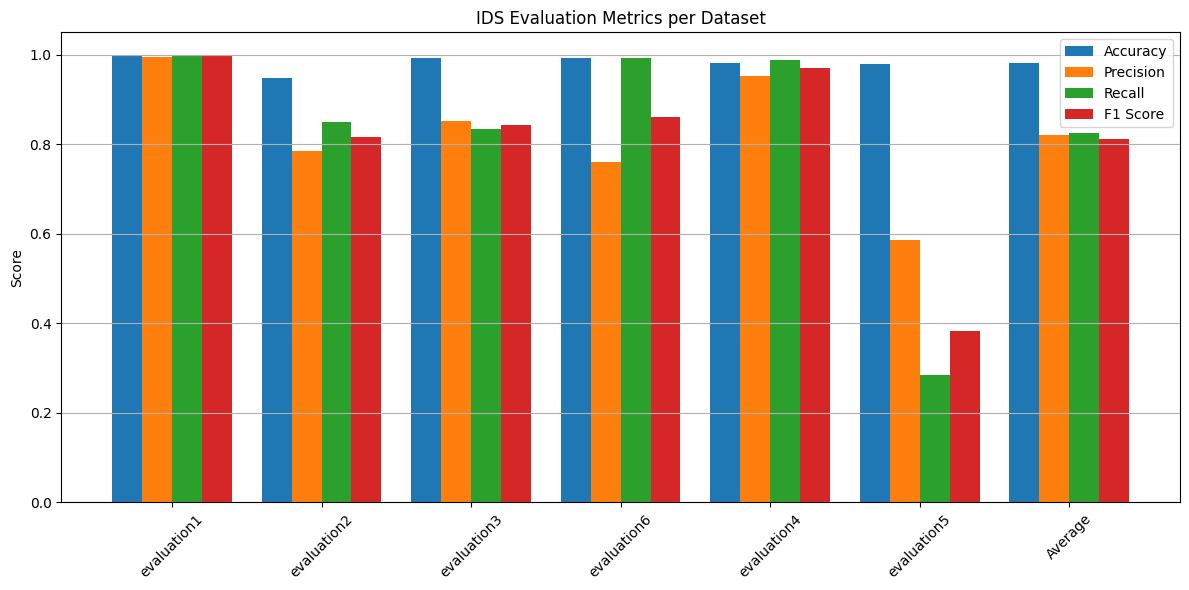


Total Elapsed Time: 759.27 seconds


In [ ]:
#evaluation sequence. Do not touch.
import time  # Add this
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

start_time = time.time()  # Start timing

evaluation_metrics = {}
all_globals = list(globals().items())

# Loop through evaluation dataframes
for name, df in all_globals:
    if name.startswith("evaluation") and isinstance(df, pd.DataFrame):
        # Run IDS
        print("running " + name)
        detected_df = ids(df)

        # Compare predictions to ground truth
        y_true = detected_df['attack']
        y_pred = detected_df['predicted_attack']

        # Compute metrics
        metrics = {
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1_score': f1_score(y_true, y_pred, zero_division=0),
        }

        evaluation_metrics[name] = metrics

# Compute average metrics
avg_metrics = {
    metric: np.mean([metrics[metric] for metrics in evaluation_metrics.values()])
    for metric in ['accuracy', 'precision', 'recall', 'f1_score']
}
evaluation_metrics['Average'] = avg_metrics

# Display metrics
for name, metrics in evaluation_metrics.items():
    print(f"\n{name} Evaluation Metrics:")
    for metric, value in metrics.items():
        print(f"  {metric.capitalize()}: {value:.4f}")

# Plotting
labels = list(evaluation_metrics.keys())
x = np.arange(len(labels))
width = 0.2

# Prepare metric lists
accuracy = [evaluation_metrics[label]['accuracy'] for label in labels]
precision = [evaluation_metrics[label]['precision'] for label in labels]
recall = [evaluation_metrics[label]['recall'] for label in labels]
f1 = [evaluation_metrics[label]['f1_score'] for label in labels]

# Create the bar chart
plt.figure(figsize=(12, 6))
plt.bar(x - 1.5*width, accuracy, width, label='Accuracy')
plt.bar(x - 0.5*width, precision, width, label='Precision')
plt.bar(x + 0.5*width, recall, width, label='Recall')
plt.bar(x + 1.5*width, f1, width, label='F1 Score')

plt.xticks(x, labels, rotation=45)
plt.ylabel('Score')
plt.title('IDS Evaluation Metrics per Dataset')
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.grid(axis='y')
plt.show()

# End timing
end_time = time.time()
elapsed_time = end_time - start_time
print(f"\nTotal Elapsed Time: {elapsed_time:.2f} seconds")
